In [ ]:
import pandas as pd
import numpy as np

# Pustaka untuk Machine Learning Pipeline dan Preprocessing
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Algoritma Random Forest
from sklearn.ensemble import RandomForestClassifier

# Visualisasi
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

# Pustaka untuk Evaluasi dan Ekspor Model
from sklearn.metrics import classification_report, accuracy_score
import joblib
import warnings
warnings.filterwarnings('ignore')

Pustaka berhasil dimuat!


LOAD DATA

In [2]:
# Memuat Master Dataset
df = pd.read_csv('dataset/data_final_siap_ml.csv', sep=';')

# Mengisi nilai kosong (NaN) untuk berjaga-jaga
df.fillna('Tidak Diketahui', inplace=True)

# 1. Menentukan Fitur (X)
# Kita memilih kolom-kolom klinis dan linguistik yang sudah kita ektrak
fitur_teks = 'Ujaran Bersih'
fitur_kategorikal = ['ASD', 'Echolalia', 'Struktur Sintaksis', 'Kompleksitas Kalimat', 'Intensi Komunikasi']
fitur_numerik = ['MLU']

X = df[[fitur_teks] + fitur_kategorikal + fitur_numerik]

# 2. Menentukan Target Label (Y)
y = df['Kategori Pemahaman']

print("Jumlah Data:", len(df))
print("\nDistribusi Kelas Target:")
print(y.value_counts())

Jumlah Data: 132

Distribusi Kelas Target:
Kategori Pemahaman
Sudah Mahir          51
Berkembang Sedang    48
Belum Berkembang     33
Name: count, dtype: int64


PREPROCESSING

In [3]:
# Membuat transformasi terpisah untuk setiap jenis data
preprocessor = ColumnTransformer(
    transformers=[
        # Teks diubah menjadi vektor menggunakan TF-IDF
        ('teks', TfidfVectorizer(max_features=100), fitur_teks),
        
        # Kategori (Ya/Tidak, ASD-1, dsb) diubah menjadi matriks biner (One-Hot)
        ('kategori', OneHotEncoder(handle_unknown='ignore'), fitur_kategorikal),
        
        # Angka (MLU) distandarisasi agar skalanya seimbang
        ('angka', StandardScaler(), fitur_numerik)
    ])

# Menggabungkan Preprocessor dengan algoritma Random Forest ke dalam satu Pipeline
pipeline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

print("Pipeline Machine Learning berhasil dirakit!")

Pipeline Machine Learning berhasil dirakit!


CROSS VALIDATION

Memulai proses Cross-Validation (5 Folds)...

Akurasi dari tiap putaran: [1.   0.96 0.96 1.   1.  ]
RATA-RATA AKURASI MODEL: 98.49%
RATA-RATA F1-SCORE: 98.34%

Membuat Visualisasi Confusion Matrix...


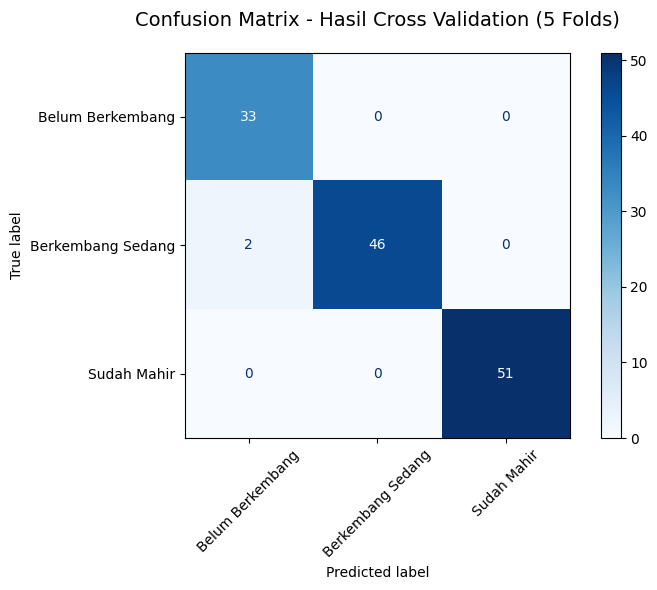

In [7]:
print("Memulai proses Cross-Validation (5 Folds)...")

# StratifiedKFold memastikan pembagian kelas target (Y) rata di setiap giliran
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Menjalankan evaluasi untuk metrik numerik
cv_results = cross_validate(pipeline_model, X, y, cv=cv_strategy, scoring=['accuracy', 'f1_macro'])

# Menampilkan hasil evaluasi nyata (tanpa ilusi overfitting)
print(f"\nAkurasi dari tiap putaran: {np.round(cv_results['test_accuracy'], 2)}")
print(f"RATA-RATA AKURASI MODEL: {cv_results['test_accuracy'].mean() * 100:.2f}%")
print(f"RATA-RATA F1-SCORE: {cv_results['test_f1_macro'].mean() * 100:.2f}%")

# ==========================================
# TAMBAHAN: VISUALISASI CONFUSION MATRIX
# ==========================================
print("\nMembuat Visualisasi Confusion Matrix...")

# Mendapatkan hasil prediksi gabungan dari ke-5 putaran (folds)
y_pred_cv = cross_val_predict(pipeline_model, X, y, cv=cv_strategy)

# Membuat tata letak gambar
fig, ax = plt.subplots(figsize=(8, 6))

# Memplot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y,                # Kunci Jawaban (Label Asli)
    y_pred_cv,        # Tebakan Model
    cmap='Blues',     # Tema warna matriks (Biru)
    ax=ax,
    xticks_rotation=45 # Memiringkan teks label agar tidak bertumpuk
)

# Menambahkan judul
plt.title("Confusion Matrix - Hasil Cross Validation (5 Folds)", pad=20, fontsize=14)
plt.tight_layout()

# Menampilkan grafik ke layar
plt.show()

TRAIN MODEL

In [ ]:
# Melatih model final menggunakan seluruh data
pipeline_model.fit(X, y)

print("Model berhasil dilatih dengan seluruh data!")

# MENYIMPAN MODEL (EXPORT)
# Model ini (lengkap dengan perubah TF-IDF dan OneHot-nya) dibungkus jadi 1 file
nama_model_ekspor = 'model_autism_syntax_rf.pkl'
joblib.dump(pipeline_model, nama_model_ekspor)

print(f"\nSUKSES! Model telah diekspor sebagai '{nama_model_ekspor}'.")
print("File .pkl ini siap dipanggil di dalam file app.py Streamlit Anda!")